In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fim import apriori, fpgrowth
from sklearn.model_selection import train_test_split

In [83]:
df = pd.read_csv("dataset/DM1_game_dataset_cleaned.csv")
df.head()

,Name,YearPublished,GameWeight,MinPlayers,MaxPlayers,MfgPlaytime,MfgAgeRec,NumAlternates,NumExpansions,NumImplementations,IsReimplementation,Kickstarted,Rating,HasFamily,Category,Rank,EngagementLevel
0,Assassin's Creed: Arena,2014,1.8333,2,4,30,15,0.000000,0.693147,0.0,0,0,Low,0,NoCategory,21926,4.744932
1,Bag of Chips,2021,1.0000,2,5,20,8,0.693147,0.000000,0.0,0,0,Medium,0,NoCategory,21926,3.772761
2,Gùgōng: Deluxe Big Box,2020,3.6667,1,5,150,12,0.000000,0.693147,0.0,0,0,High,0,NoCategory,21926,4.997212
3,LetterFlip,2004,1.3077,2,2,20,10,0.000000,0.000000,0.0,0,0,Low,0,NoCategory,21926,3.806662
4,Treasures of Cibola,2019,1.5000,2,4,20,8,1.386294,0.000000,0.0,0,0,Medium,0,NoCategory,21926,4.060443


# Preprocessing

In [84]:
# remove useless variables
column2drop = "Name"
df.drop(column2drop, axis=1, inplace=True)

In [85]:
# handling categorical variables -> one-hot encoding
df = pd.get_dummies(df, columns=["Category"])
# replacing boolean values with string values
'''df["Category_Abstract"] = df["Category_Abstract"].replace({True: "Abstract", False: "Not Abstract"})
df["Category_CGS"] = df["Category_CGS"].replace({True: "CGS", False: "Not CGS"})
df["Category_Childrens"] = df["Category_Childrens"].replace({True: "Childrens", False: "Not Childrens"})
df["Category_Family"] = df["Category_Family"].replace({True: "Family", False: "Not Family"})
df["Category_NoCategory"] = df["Category_NoCategory"].replace({True: "NoCategory", False: "HasCategory"})
df["Category_Party"] = df["Category_Party"].replace({True: "Party", False: "Not Party"})
df["Category_Strategy"] = df["Category_Strategy"].replace({True: "Strategy", False: "Not Strategy"})
df["Category_Thematic"] = df["Category_Thematic"].replace({True: "Thematic", False: "Not Thematic"})
df["Category_War"] = df["Category_War"].replace({True: "War", False: "Not War"})'''
df["Category_Bin"] = df["Category_NoCategory"].replace({True: "NoCategory", False: "HasCategory"})
'''df["Rating_High"] = df["Rating_High"].replace({True: "High Rating", False: "Not High Rating"})
df["Rating_Low"] = df["Rating_Low"].replace({True: "Low Rating", False: "Not Low Rating"})
df["Rating_Medium"] = df["Rating_Medium"].replace({True: "Medium Rating", False: "Not Medium Rating"})'''
df["Rating"].replace({"High": "High_Rating", "Low": "Low_Rating", "Medium": "Medium_Rating"}, inplace=True)
df["HasFamily"] = df["HasFamily"].replace({1: "Has Family", 0: "Not Has Family"})
df["IsReimplementation"] = df["IsReimplementation"].replace({1: "Is Reimplementation", 0: "OriginalGame"})
df["Kickstarted"] = df["Kickstarted"].replace({1: "Is Kickstarted", 0: "Not Kickstarted"})
df.head()
df.columns

C:\Users\leona\AppData\Local\Temp\ipykernel_2248\3202080234.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Rating"].replace({"High": "High_Rating", "Low": "Low_Rating", "Medium": "Medium_Rating"}, inplace=True)


Index(['YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
       'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions',
       'NumImplementations', 'IsReimplementation', 'Kickstarted', 'Rating',
       'HasFamily', 'Rank', 'EngagementLevel', 'Category_Abstract',
       'Category_CGS', 'Category_Childrens', 'Category_Family',
       'Category_NoCategory', 'Category_Party', 'Category_Strategy',
       'Category_Thematic', 'Category_War', 'Category_Bin'],
      dtype='object')

In [143]:
df[df["Rank"]!=21926]["Rank"].max()

3531

In [ ]:
# --- 1. GESTIONE RANK (Manuale) ---
def discretize_rank(val):
    if val == 21926: # O il valore che indica "fuori classifica"
        return "Unranked"
    elif val <= 500:
        return "Top500"
    elif val <= 1000:
        return "Top1000"
    elif val <= 2000:
        return "Top2000"
    elif val <= 4000:
        return "Top4000" # max is 3531

# Applichiamo la funzione e aggiungiamo il suffisso per chiarezza nel mining
df["Rank_Bin"] = df["Rank"].apply(discretize_rank) + "_Rank"


# --- 2. GESTIONE VARIABILI CONTINUE (GameWeight, Engagement) ---
# Qui qcut va bene perché sono distribuzioni continue
# Aggiungo label=False e poi rimappo per avere nomi puliti, oppure uso direttamente le etichette
labels_weight = ["Light", "MediumLight", "MediumHeavy", "Heavy"]
df["GameWeight_Bin"] = pd.qcut(df["GameWeight"], 4, labels=labels_weight).astype(str) + "_Weight"

labels_eng = ["Low", "Medium", "High", "VeryHigh"]
df["Engagement_Bin"] = pd.qcut(df["EngagementLevel"], 4, labels=labels_eng).astype(str) + "_Engagement"


# --- 3. GESTIONE VARIABILI DISCRETE / CONTEGGI ---
# Per il pattern mining è meglio avere stringhe esplicite ("HasExpansions") 
# piuttosto che 0/1.

df["Expansions_Bin"] = np.where(df["NumExpansions"] > 0, "HasExpansions", "NoExpansions")
df["Implementation_Bin"] = np.where(df["NumImplementations"] > 0, "HasImplementations", "NoImplementations")
df["Alternates_Bin"] = np.where(df["NumAlternates"] > 0, "HasAlternates", "NoAlternates")
# NumAlternates forse è meno rilevante, puoi decidere se tenerlo


# --- 4. SUGGERIMENTI PER ALTRE VARIABILI ---

# PlayTime: taglio manuale basato sulla logica dei giochi
bins_time = [0, 30, 90, 180, 70000]
labels_time = ["Rapid(<30)", "Standard(30-90)", "Long(90-180)", "VeryLong(>180)"]
df["PlayTime_Bin"] = pd.cut(df["MfgPlaytime"], bins=bins_time, labels=labels_time).astype(str) + "_Time"

# YearPublished: Decenni
# (Esempio semplificato, aggiusta i bin in base al tuo range di anni)
bins_year = [-5000, 0, 1990, 2000, 2010, 2015, 2022] 
labels_year = ["Ancient", "Vintage", "90s", "00s", "Early10s", "Modern"]
df["Year_Bin"] = pd.cut(df["YearPublished"], bins=bins_year, labels=labels_year).astype(str) + "_Year"

# MfgAgeRec
bins_age = [0, 7, 13, 99]
labels_age = ["Kids(<8)", "PreTeen(8-13)", "Teen/Adult(14+)"]
df["AgeRec_Bin"] = pd.cut(df["MfgAgeRec"], bins=bins_age, labels=labels_age).astype(str) + "_AgeRec"

# MinPlayers: Categorico puro (visto che sono pochi valori)
# Convertiamo direttamente in stringa es: "2_MinPlayers"
# bins_MinPlayers = [0,1,2,3,100]
# labels_MinPlayers = ["0_MinPlayers","1_MinPlayers", "2_MinPlayers", "3+_MinPlayers"]
# df["MinPlayers_Bin"] = pd.cut(df["MinPlayers"], bins=bins_MinPlayers, labels=labels_MinPlayers).astype(str)

# PlayersRange "Solo", "Duel", "SmallGroup", "Party"
def discretize_rank(val1, val2):
    if val1 == 1 and val2 == 1: # O il valore che indica "fuori classifica"
        return "Solo"
    elif val1 == 2 and val2 == 2:
        return "Duel"
    elif val1 <= 5 and val2 <= 5:
        return "SmallGroup"
    else:
        return "Party"

# Applichiamo la funzione e aggiungiamo il suffisso per chiarezza nel mining
df["PlayerRange_Bin"] = df.apply(lambda row: discretize_rank(row["MinPlayers"], row["MaxPlayers"]), axis=1) + "_PlayerRange"

# --- 5. PREPARAZIONE FINALE ---
# Selezioniamo solo le colonne discretizzate per il pattern mining
cols_for_mining = [
    "Rank_Bin", "GameWeight_Bin", "Engagement_Bin",
    "Alternates_Bin", "AgeRec_Bin",
    "Expansions_Bin", "Implementation_Bin", 
    "PlayTime_Bin", "Year_Bin", "PlayerRange_Bin",
    "HasFamily", "IsReimplementation", "Kickstarted",
    'Category_Bin', 'Rating'
]

df_mining = df[cols_for_mining].copy()

# VISUALIZZAZIONE ESEMPIO
print(df_mining.head())


        Rank_Bin      GameWeight_Bin     Engagement_Bin Alternates_Bin  \
0  Unranked_Rank  MediumLight_Weight    High_Engagement   NoAlternates   
1  Unranked_Rank        Light_Weight  Medium_Engagement  HasAlternates   
2  Unranked_Rank        Heavy_Weight    High_Engagement   NoAlternates   
3  Unranked_Rank        Light_Weight  Medium_Engagement   NoAlternates   
4  Unranked_Rank  MediumLight_Weight  Medium_Engagement  HasAlternates   

               AgeRec_Bin Expansions_Bin Implementation_Bin  \
0  Teen/Adult(14+)_AgeRec  HasExpansions  NoImplementations   
1    PreTeen(8-13)_AgeRec   NoExpansions  NoImplementations   
2    PreTeen(8-13)_AgeRec  HasExpansions  NoImplementations   
3    PreTeen(8-13)_AgeRec   NoExpansions  NoImplementations   
4    PreTeen(8-13)_AgeRec   NoExpansions  NoImplementations   

        PlayTime_Bin       Year_Bin         PlayerRange_Bin       HasFamily  \
0    Rapid(<30)_Time  Early10s_Year  SmallGroup_PlayerRange  Not Has Family   
1    Rapid(<30)_Ti

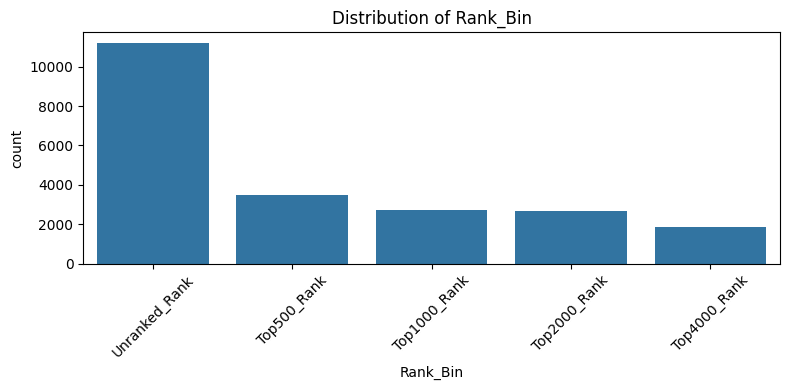

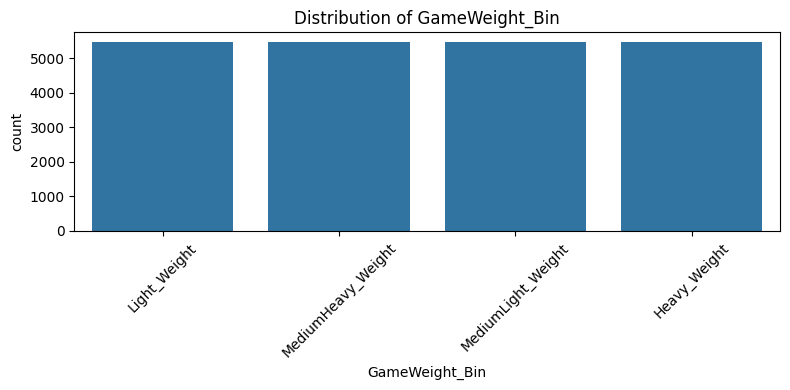

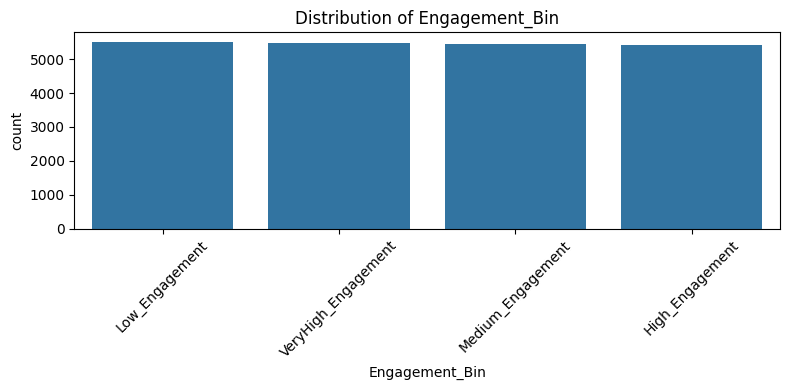

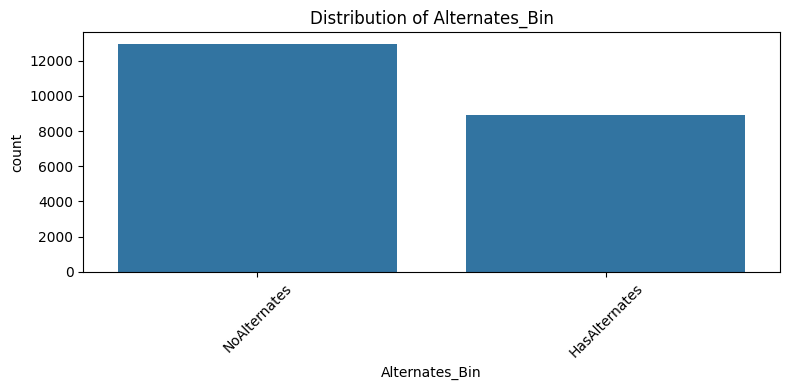

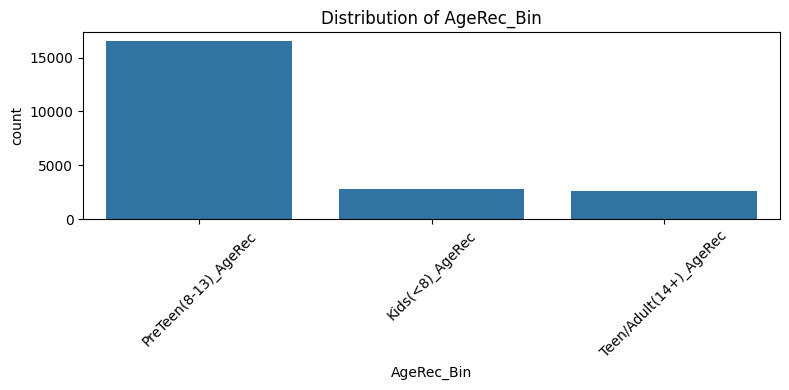

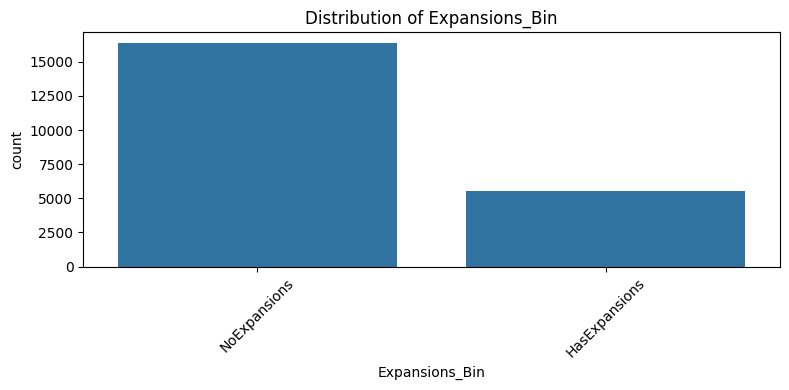

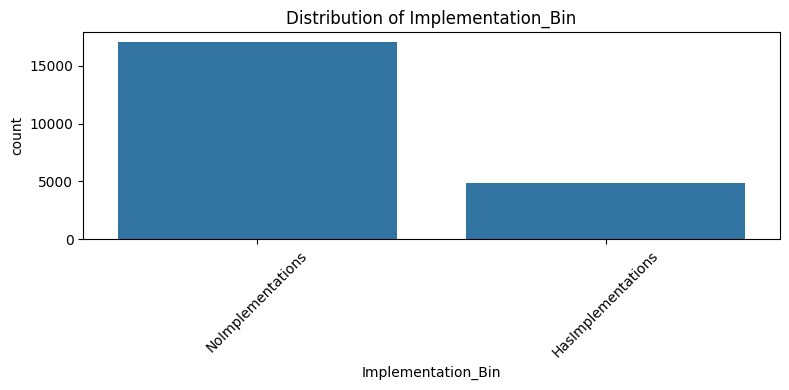

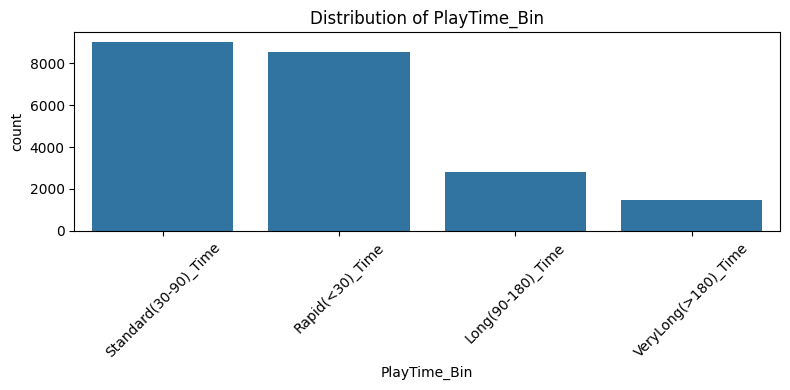

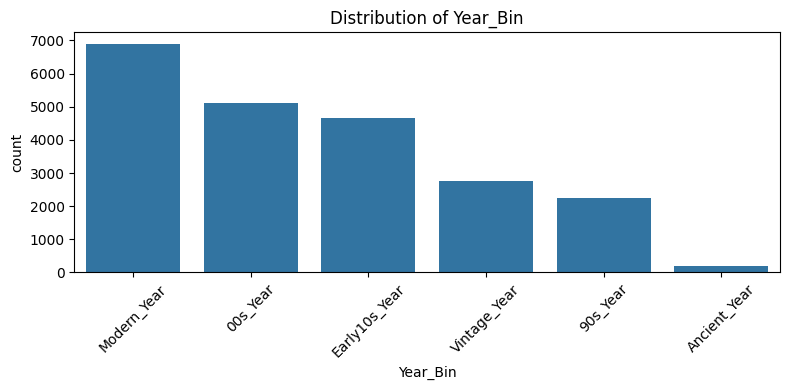

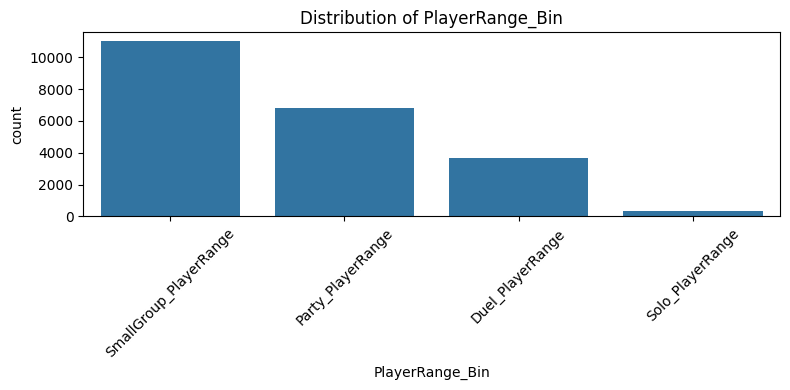

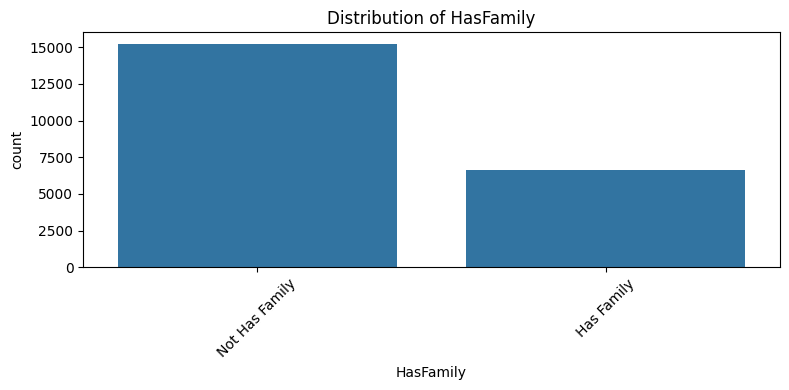

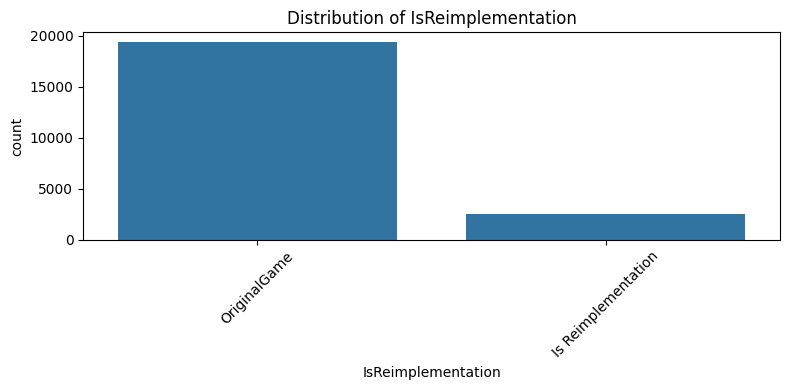

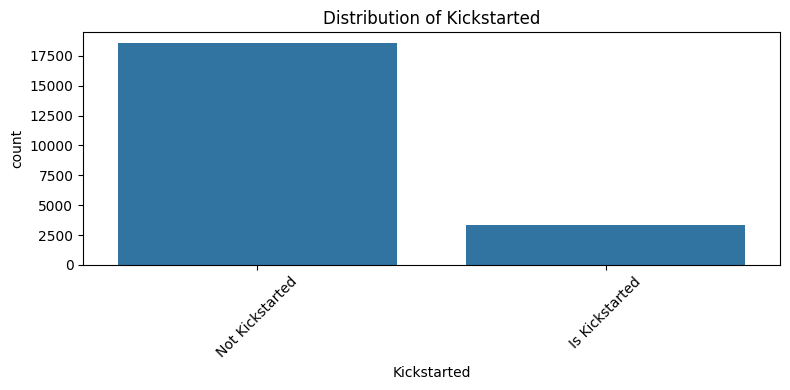

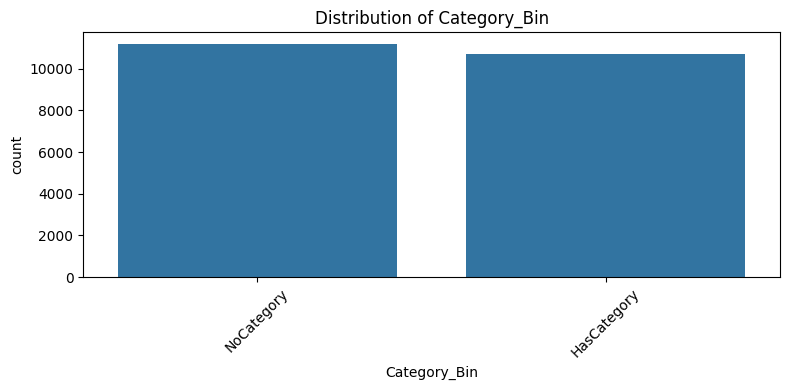

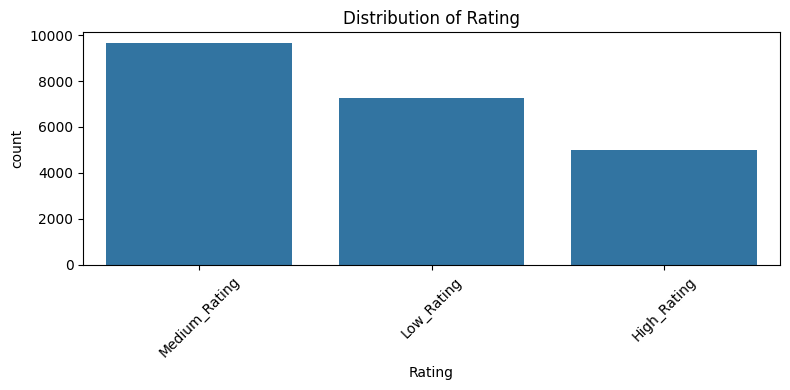

Number of records with NaN Year_Bin: 0
Number of records with NaN PlayTime_Bin: 0


In [145]:
# plot distributions of discretized variables
for col in cols_for_mining:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_mining, x=col, order=df_mining[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
# count nan_year and nan_Time records
nan_year_count = df_mining[df_mining['Year_Bin']=="nan_Year"].shape[0]
nan_time_count = df_mining[df_mining['PlayTime_Bin']=="nan_Time"].shape[0]
print(f'Number of records with NaN Year_Bin: {nan_year_count}')
print(f'Number of records with NaN PlayTime_Bin: {nan_time_count}')

In [120]:
X = df_mining.values.tolist()

In [121]:
X[0]

['Unranked_Rank',
 'MediumLight_Weight',
 'High_Engagement',
 'NoAlternates',
 'Teen/Adult(14+)_AgeRec',
 'HasExpansions',
 'NoImplementations',
 'Rapid(<30)_Time',
 'Early10s_Year',
 'SmallGroup_PlayerRange',
 'Not Has Family',
 'OriginalGame',
 'Not Kickstarted',
 'NoCategory',
 'Low_Rating']

# Apriori
- frequent itemset >= min_supp

- closed: an itemset is closed if none of its immediate supersets has the same support as the itemset

- maximal: an itemset is maximal frequent if none of its immediate supersets is frequent

## 1. Frequent Itemset

In [410]:
# voglio regole che valgano per almeno il tot% di transazioni (o record, in questo caso)
# supp = 2  # 2%
supp = 10  # 10% (threshold più alto per ridurre il numero di itemset) -> numero di volte in cui compare la tranzasione X/tutte le transazioni
zmin = 2  # minimum number of items per item set

itemsets = apriori(X, target="s", supp=supp, zmin=zmin, report="S") # report="S" means report only support  
pd.DataFrame(itemsets, columns=["frequent_itemset", "support"])

,frequent_itemset,support
0,"(90s_Year, Not Kickstarted)",10.196993
1,"(2_MinPlayers, Not Kickstarted)",10.169569
2,"(2_MinPlayers, OriginalGame)",10.014169
3,"(Is Reimplementation, HasImplementations)",11.563600
4,"(Is Reimplementation, Not Kickstarted, HasImplementations)",10.014169
...,...,...
4125,"(NoExpansions, OriginalGame)",67.055167
4126,"(NoImplementations, OriginalGame)",77.928607
4127,"(NoImplementations, Not Kickstarted, OriginalGame)",65.478313
4128,"(NoImplementations, Not Kickstarted)",65.478313


In [411]:
# return only top 10 itemsets by support
pd.DataFrame(itemsets, columns=["frequent_itemset", "support"]).sort_values(by="support", ascending=False).head(20)

,frequent_itemset,support
4126,"(NoImplementations, OriginalGame)",77.928607
4129,"(Not Kickstarted, OriginalGame)",74.724622
4123,"(NoExpansions, Not Kickstarted)",67.402532
4125,"(NoExpansions, OriginalGame)",67.055167
4128,"(NoImplementations, Not Kickstarted)",65.478313
4127,"(NoImplementations, Not Kickstarted, OriginalGame)",65.478313
4118,"(Not Has Family, OriginalGame)",64.189405
4103,"(1_MinPlayers, OriginalGame)",60.939714
4120,"(NoExpansions, NoImplementations)",60.505508
4119,"(NoExpansions, NoImplementations, OriginalGame)",60.505508


## 2. Closed Itemset

In [412]:
# supp = 2  # 2%
supp = 10  # 10%
zmin = 2  # minimum number of items per item set

itemsets = apriori(X, target="c", supp=supp, zmin=zmin, report="S")
pd.DataFrame(itemsets, columns=["closed_itemset", "support"])

,closed_itemset,support
0,"(90s_Year, Not Kickstarted)",10.196993
1,"(2_MinPlayers, Not Kickstarted)",10.169569
2,"(2_MinPlayers, OriginalGame)",10.014169
3,"(Is Reimplementation, HasImplementations)",11.563600
4,"(Is Reimplementation, HasImplementations, Not Kickstarted)",10.014169
...,...,...
2219,"(NoExpansions, Not Kickstarted, OriginalGame)",60.491796
2220,"(NoExpansions, OriginalGame)",67.055167
2221,"(NoImplementations, Not Kickstarted, OriginalGame)",65.478313
2222,"(NoImplementations, OriginalGame)",77.928607


In [413]:
# return only top 20 closed itemsets by support -> useful to find longest itemsets
pd.DataFrame(itemsets, columns=["closed_itemset", "support"]).sort_values(by="support", ascending=False).head(20)

,closed_itemset,support
2222,"(NoImplementations, OriginalGame)",77.928607
2223,"(Not Kickstarted, OriginalGame)",74.724622
2218,"(NoExpansions, Not Kickstarted)",67.402532
2220,"(NoExpansions, OriginalGame)",67.055167
2221,"(NoImplementations, Not Kickstarted, OriginalGame)",65.478313
2215,"(Not Has Family, OriginalGame)",64.189405
2204,"(1_MinPlayers, OriginalGame)",60.939714
2217,"(NoExpansions, NoImplementations, OriginalGame)",60.505508
2219,"(NoExpansions, Not Kickstarted, OriginalGame)",60.491796
2202,"(1_MinPlayers, Not Kickstarted)",59.893048


## 3. Maximal Itemset

In [414]:
itemsets = apriori(X, target="m", supp=supp, zmin=zmin, report="S")
pd.DataFrame(itemsets, columns=["maximal_itemset", "support"])

,maximal_itemset,support
0,"(90s_Year, Not Kickstarted)",10.196993
1,"(2_MinPlayers, Not Kickstarted)",10.169569
2,"(2_MinPlayers, OriginalGame)",10.014169
3,"(Is Reimplementation, HasImplementations, Not Kickstarted)",10.014169
4,"(Vintage_Year, 1_MinPlayers, Not Kickstarted)",10.037022
...,...,...
486,"(HasCategory, NoAlternates, Not Has Family, NoExpansions, NoImplementations, OriginalGame)",10.169569
487,"(HasCategory, NoAlternates, Not Has Family, NoExpansions, Not Kickstarted, OriginalGame)",10.580922
488,"(HasCategory, NoAlternates, Not Has Family, NoImplementations, Not Kickstarted, OriginalGame)",11.129393
489,"(HasCategory, 1_MinPlayers, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",12.738242


In [415]:
# return top 20 maximal itemsets by support -> useful to find most general patterns
pd.DataFrame(itemsets, columns=["maximal_itemset", "support"]).sort_values(by="support", ascending=False).head(20)

,maximal_itemset,support
359,"(Low_Rating, 1_MinPlayers, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",14.566479
402,"(Rapid(<30)_Time, 1_MinPlayers, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",13.762055
295,"(Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",13.606655
43,"(HasImplementations, 1_MinPlayers, Not Kickstarted)",13.364413
13,"(0_MinPlayers, NoImplementations, OriginalGame)",13.327849
45,"(HasImplementations, NoExpansions, Not Kickstarted)",13.067325
219,"(Light_Weight, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",12.838795
489,"(HasCategory, 1_MinPlayers, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",12.738242
272,"(HasExpansions, HasCategory, OriginalGame)",12.605695
242,"(MediumHeavy_Weight, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",12.578271


## Support Plot

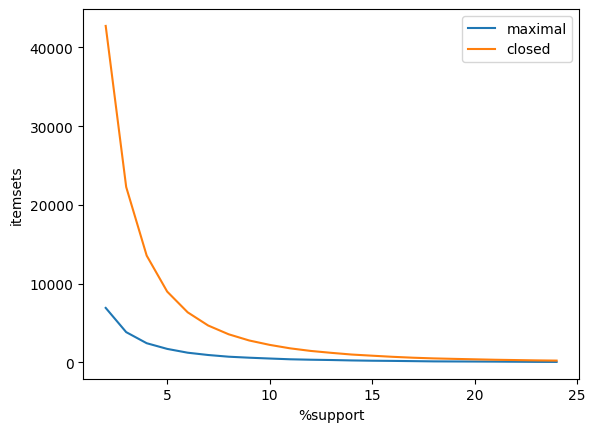

In [416]:
# Variazione del numero di itemset (maximal e closed) in funzione del supporto minimo
len_max_it = []
len_cl_it = []
max_supp = 25
for i in range(2, max_supp):
    max_itemsets = apriori(X, target="m", supp=i, zmin=zmin)
    cl_itemsets = apriori(X, target="c", supp=i, zmin=zmin)
    len_max_it.append(len(max_itemsets))
    len_cl_it.append(len(cl_itemsets))

plt.plot(np.arange(2, max_supp), len_max_it, label="maximal")
plt.plot(np.arange(2, max_supp), len_cl_it, label="closed")
plt.legend()
plt.xlabel("%support")
plt.ylabel("itemsets")

plt.show()

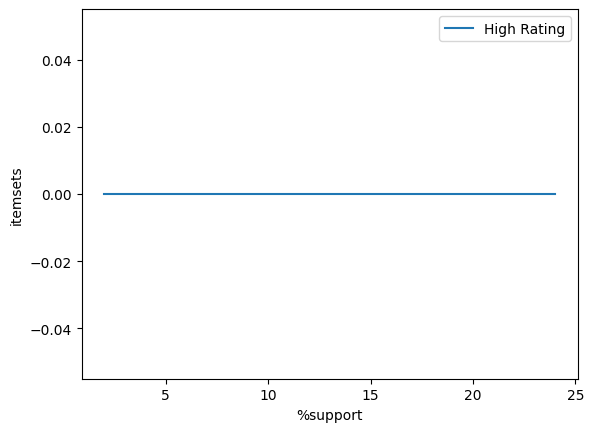

In [417]:
# Variazione del numero di itemset (maximal) contenenti "Survived" o "Not Survived" in funzione del supporto minimo
filter_1 = []
filter_2 = []
max_supp = 25
for i in range(2, max_supp):
    max_itemsets = apriori(X, target="m", supp=i, zmin=zmin)
    filter_1.append(len([item for item in max_itemsets if "High Rating" in item[0]]))
#   filter_2.append(len([item for item in max_itemsets if "Not High Rating" in item[0]]))

plt.plot(np.arange(2, max_supp), filter_1, label="High Rating")
# plt.plot(np.arange(2, max_supp), filter_2, label="Not High Rating")
plt.legend()
plt.xticks()
plt.xlabel("%support")
plt.ylabel("itemsets")

plt.show()

## 4. Rules

In [418]:
conf = 50 # minimum confidence in %
rules = apriori(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl") # report antecedent, support, confidence, lift
rules_df = pd.DataFrame(
    rules,
    columns=[
        "consequent",
        "antecedent",
        "abs_support",
        "%_support",
        "confidence",
        "lift",
    ],
)
rules_df = rules_df[rules_df["lift"] > 1]
rules_df.sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
43,Is Reimplementation,"(HasImplementations, Has Family)",1317,6.019471,0.591113,5.111843
49,Is Reimplementation,"(HasImplementations, NoAlternates)",1360,6.216006,0.558751,4.831982
57,Is Reimplementation,"(HasImplementations, NoExpansions)",1664,7.605466,0.537294,4.646426
55,Is Reimplementation,"(HasImplementations, NoExpansions, Not Kickstarted)",1512,6.910736,0.528856,4.573457
62,Is Reimplementation,"(HasImplementations,)",2530,11.563600,0.523918,4.530752
...,...,...,...,...,...,...
25197,1_MinPlayers,"(Unranked_Rank, Not Has Family, NoExpansions, Not Kickstarted, OriginalGame)",3879,17.729329,0.687035,1.000043
24561,1_MinPlayers,"(Unranked_Rank, NoCategory, Not Has Family, NoExpansions, Not Kickstarted, OriginalGame)",3879,17.729329,0.687035,1.000043
5021,1_MinPlayers,"(VeryHigh_Engagement, HasCategory, NoExpansions)",1620,7.404360,0.687023,1.000025
5032,Not Kickstarted,"(VeryHigh_Engagement, HasCategory, 1_MinPlayers, OriginalGame)",2099,9.593674,0.847396,1.000010


In [419]:
# return top 20 rules by lift
pd.DataFrame(rules, columns=["consequent", "antecedent", "abs_support", "%_support", "confidence", "lift"]).sort_values(by="lift", ascending=False).head(20)

# enlarge width of displayed dataframe
pd.set_option('display.max_colwidth', None)
pd.DataFrame(rules, columns=["consequent", "antecedent", "abs_support", "%_support", "confidence", "lift"]).sort_values(by="lift", ascending=False).head(40)



,consequent,antecedent,abs_support,%_support,confidence,lift
43,Is Reimplementation,"(HasImplementations, Has Family)",1317,6.019471,0.591113,5.111843
49,Is Reimplementation,"(HasImplementations, NoAlternates)",1360,6.216006,0.558751,4.831982
57,Is Reimplementation,"(HasImplementations, NoExpansions)",1664,7.605466,0.537294,4.646426
55,Is Reimplementation,"(HasImplementations, NoExpansions, Not Kickstarted)",1512,6.910736,0.528856,4.573457
62,Is Reimplementation,"(HasImplementations,)",2530,11.563600,0.523918,4.530752
61,HasImplementations,"(Is Reimplementation,)",2530,11.563600,1.000000,4.530752
59,HasImplementations,"(Is Reimplementation, Not Kickstarted)",2191,10.014169,1.000000,4.530752
53,Is Reimplementation,"(HasImplementations, 1_MinPlayers)",1698,7.760867,0.521339,4.508446
51,Is Reimplementation,"(HasImplementations, 1_MinPlayers, Not Kickstarted)",1522,6.956442,0.520520,4.501365
60,Is Reimplementation,"(HasImplementations, Not Kickstarted)",2191,10.014169,0.519934,4.496295


In [420]:
rules_df[rules_df["consequent"] == "VeryHigh_Engagement"].sort_values(by="lift", ascending=False)


,consequent,antecedent,abs_support,%_support,confidence,lift
4769,VeryHigh_Engagement,"(HasExpansions, HasAlternates)",1675,7.655743,0.711555,2.846610
4797,VeryHigh_Engagement,"(Has Family, HasAlternates, HasCategory)",1538,7.029572,0.689686,2.759123
4786,VeryHigh_Engagement,"(HasExpansions, HasCategory)",2259,10.324969,0.677971,2.712257
4784,VeryHigh_Engagement,"(HasExpansions, HasCategory, OriginalGame)",1849,8.451026,0.670413,2.682021
4781,VeryHigh_Engagement,"(HasExpansions, HasCategory, Not Kickstarted)",1609,7.354084,0.649314,2.597612
4820,VeryHigh_Engagement,"(HasAlternates, Medium_Rating, HasCategory)",1516,6.929019,0.638854,2.555766
2725,VeryHigh_Engagement,"(Top1000_Rank, Medium_Rating, HasCategory)",1536,7.020431,0.634449,2.538142
2732,VeryHigh_Engagement,"(Top1000_Rank, Medium_Rating)",1536,7.020431,0.634449,2.538142
4778,VeryHigh_Engagement,"(HasExpansions, HasCategory, 1_MinPlayers)",1415,6.467389,0.633393,2.533920
2704,VeryHigh_Engagement,"(Top1000_Rank, HasAlternates, HasCategory)",1963,8.972074,0.624364,2.497798


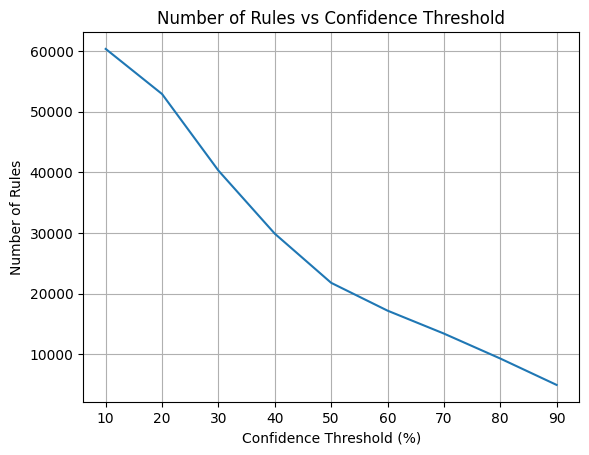

In [421]:
# number of rules with varying confidence thresholds
conf_levels = range(10, 100, 10)
num_rules_per_conf = []
for conf in conf_levels:
    rules = apriori(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl")
    rules_df = pd.DataFrame(
        rules,
        columns=[
            "consequent",
            "antecedent",
            "abs_support",
            "%_support",
            "confidence",
            "lift",
        ],
    )
    rules_df = rules_df[rules_df["lift"] > 1]
    num_rules_per_conf.append(len(rules_df))
plt.plot(conf_levels, num_rules_per_conf, marker=None)
plt.xlabel("Confidence Threshold (%)")
plt.ylabel("Number of Rules")
plt.title("Number of Rules vs Confidence Threshold")
plt.xticks(conf_levels)
plt.grid()
plt.show()


## 5. Classification

Default Class: Low_Engagement
Esecuzione Apriori...
Regole totali ibride: 386
Regole usate per il voto: 386
Inizio predizione (Voting)...
------------------------------
F1-Score (Weighted): 0.4025
Copertura Regole: 100.00%

--- Classification Report ---
                     precision    recall  f1-score   support

    High_Engagement       0.43      0.17      0.24      1662
     Low_Engagement       0.42      0.48      0.45      1613
  Medium_Engagement       0.34      0.29      0.31      1658
VeryHigh_Engagement       0.49      0.81      0.61      1631

           accuracy                           0.43      6564
          macro avg       0.42      0.44      0.40      6564
       weighted avg       0.42      0.43      0.40      6564


--- Confusion Matrix ---
[[ 778  451   80  304]
 [ 590  480  157  431]
 [ 395  365  276  626]
 [  83  100  130 1318]]


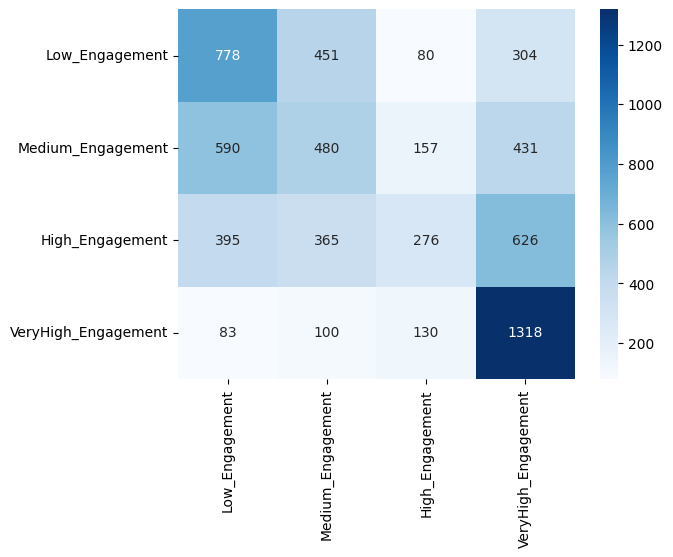

In [422]:
from collections import Counter
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# --- 1. PREPARAZIONE ---
# X deve essere una lista di liste (transazioni)
target_classes = {"Low_Engagement", "Medium_Engagement", "High_Engagement", "VeryHigh_Engagement"}

x_train, x_test = train_test_split(X, test_size=0.3, random_state=0)

# Calcoliamo la Default Class (Majority Class)
train_labels = [next((item for item in rec if item in target_classes), None) for rec in x_train]
default_class = Counter(train_labels).most_common(1)[0][0]
print(f"Default Class: {default_class}")


# --- 2. MINING E PRUNING INTELLIGENTE ---
print("Esecuzione Apriori...")
# Usiamo zmin=2 per evitare regole vuote o banali
rules_raw = apriori(x_train, target="r", supp=supp, zmin=2, conf=20, report="aScl") 

rules_df = pd.DataFrame(
    rules_raw,
    columns=["consequent", "antecedent", "abs_supp", "%_supp", "conf", "lift"]
)

# Filtriamo solo le regole che predicono il target
rules_df = rules_df[rules_df["consequent"].isin(target_classes) & (rules_df["lift"] > 1)]

# 1. Calcoliamo le Top per LIFT (Qualità)
top_lift = rules_df.sort_values(by="lift", ascending=False).groupby("consequent").head(50)

# 2. Calcoliamo le Top per SUPPORT (Quantità/Copertura)
top_supp = rules_df.sort_values(by="%_supp", ascending=False).groupby("consequent").head(50)

# 3. Uniamo i due set e rimuoviamo duplicati
# (Usiamo l'ID della regola o resettiamo l'indice per unire)
combined_rules = pd.concat([top_lift, top_supp]).drop_duplicates(subset=["consequent", "antecedent"])

print(f"Regole totali ibride: {len(combined_rules)}")


rules_pruned = combined_rules

voting_rules = []
for _, row in rules_pruned.iterrows():
    voting_rules.append({
        "consequent": row["consequent"],
        "antecedent": set(row["antecedent"]),
        "lift": row["lift"],   # Il "peso" del voto
        "conf": row["conf"]    # Alternativa: usare confidenza
    })

print(f"Regole usate per il voto: {len(voting_rules)}")

# --- 2. FUNZIONE DI PREDIZIONE (WEIGHTED VOTING) ---

def predict_voting(record, rules, default_class):
    record_set = set(record)
    
    # Inizializziamo i punteggi per ogni classe a 0
    # Assicurati che score_board contenga tutte le tue classi
    score_board = {cls: 0 for cls in target_classes}
    
    rules_triggered = 0
    
    for rule in rules:
        # Se la regola si applica al record
        if rule["antecedent"].issubset(record_set):
            # Aggiungiamo il Lift al punteggio della classe predetta
            # (Puoi provare anche rule["conf"] o rule["lift"] * rule["conf"])
            score_board[rule["consequent"]] += rule["lift"]
            rules_triggered += 1
            
    # Se nessuna regola si è attivata, usiamo il default
    if rules_triggered == 0:
        return default_class
    
    # Restituiamo la classe con il punteggio più alto
    return max(score_board, key=score_board.get)

# --- 3. VALUTAZIONE ---
correct = 0
total = 0
uncovered_count = 0

# --- LISTE PER SALVARE I RISULTATI ---
y_true = []
y_pred = []

# Variabili per statistiche interne (opzionale)
uncovered_count = 0 

print("Inizio predizione (Voting)...")

for record in x_test:
    # 1. Estrazione Ground Truth
    true_label = next((item for item in record if item in target_classes), None)
    
    # 2. Pulizia record per il test
    record_features = [item for item in record if item not in target_classes]
    
    if true_label:
        # Eseguiamo la predizione
        prediction = predict_voting(record_features, voting_rules, default_class)
        
        # Salviamo nelle liste per sklearn
        y_true.append(true_label)
        y_pred.append(prediction)
        
        # Controllo di copertura (se nessuna regola si è attivata)
        matches_any = any(rule["antecedent"].issubset(set(record_features)) for rule in voting_rules)
        if not matches_any:
            uncovered_count += 1

# --- CALCOLO METRICHE ---

# 1. F1 Score Globale (Weighted è meglio se le classi sono sbilanciate)
f1 = f1_score(y_true, y_pred, average='weighted')

print("-" * 30)
print(f"F1-Score (Weighted): {f1:.4f}")
print(f"Copertura Regole: {((len(y_true) - uncovered_count) / len(y_true))*100:.2f}%")

# 2. Report Dettagliato (F1 per ogni classe)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred))

# 3. Matrice di Confusione (Opzionale ma utilissima per capire gli errori)
# Ti mostra se il modello confonde classi vicine (es. High vs VeryHigh)
cm = confusion_matrix(y_true, y_pred, labels=list(target_classes))
print("\n--- Confusion Matrix ---")
#heatmap per visualizzare meglio
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_classes, yticklabels=target_classes, cmap='Blues')
print(cm)

# FP-Growth

In [146]:
zmin = 2
len_r = []
min_sup = 1
max_sup = 20
min_conf = 50
max_conf = 90
for i in range(min_sup, max_sup):  # support
    len_r_wrt_i = []
    for j in range(min_conf, max_conf, 5):  # confidence
        rules = fpgrowth(X, target="r", supp=i, zmin=zmin, conf=j, report="aScl")
        len_r_wrt_i.append(len(rules))  # study your characteristics/properties here

    len_r.append(len_r_wrt_i)
len_r = np.array(len_r)

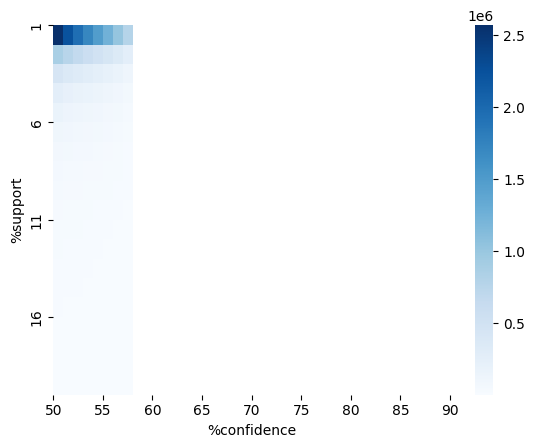

In [147]:
sns.heatmap(len_r, cmap="Blues", fmt='g')
plt.yticks(np.arange(0, max_sup-min_sup +1, 5), np.arange(min_sup, max_sup+1,5 ))
plt.xticks(np.arange(0, max_conf-min_conf+1, 5), np.arange(min_conf, max_conf+1, 5))
plt.xlabel("%confidence")
plt.ylabel("%support")
plt.show()

### Choosing min_supp 

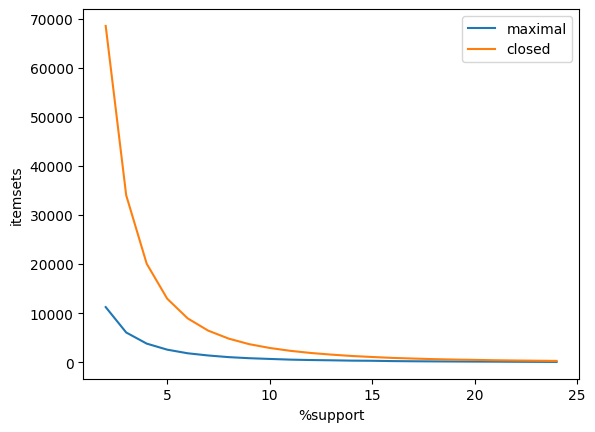

In [148]:
zmin = 2  # minimum number of items per item set

# Variazione del numero di itemset (maximal e closed) in funzione del supporto minimo
len_max_it = []
len_cl_it = []
max_supp = 25
for i in range(2, max_supp):
    max_itemsets = fpgrowth(X, target="m", supp=i, zmin=zmin)
    cl_itemsets = fpgrowth(X, target="c", supp=i, zmin=zmin)
    len_max_it.append(len(max_itemsets))
    len_cl_it.append(len(cl_itemsets))

plt.plot(np.arange(2, max_supp), len_max_it, label="maximal")
plt.plot(np.arange(2, max_supp), len_cl_it, label="closed")
plt.legend()
plt.xlabel("%support")
plt.ylabel("itemsets")

plt.show()

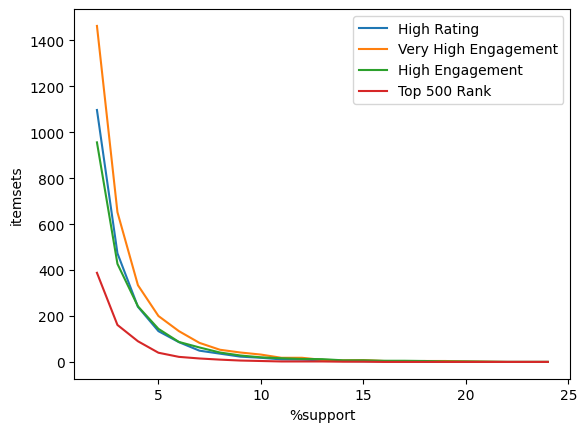

In [149]:
# Variazione del numero di itemset (maximal) contenenti "High Rating" o "Very High Engagement" in funzione del supporto minimo
filter_1 = []
filter_2 = []
filter_3 = []
filter_4 = []
max_supp = 25
for i in range(2, max_supp):
    max_itemsets = fpgrowth(X, target="m", supp=i, zmin=zmin)
    filter_1.append(len([item for item in max_itemsets if "High_Rating" in item[0]]))
    filter_2.append(len([item for item in max_itemsets if "VeryHigh_Engagement" in item[0]]))
    filter_3.append(len([item for item in max_itemsets if "High_Engagement" in item[0]]))
    filter_4.append(len([item for item in max_itemsets if "Top500_Rank" in item[0]]))

plt.plot(np.arange(2, max_supp), filter_1, label="High Rating")
plt.plot(np.arange(2, max_supp), filter_2, label="Very High Engagement")
plt.plot(np.arange(2, max_supp), filter_3, label="High Engagement")
plt.plot(np.arange(2, max_supp), filter_4, label="Top 500 Rank")
plt.legend()
plt.xticks()
plt.xlabel("%support")
plt.ylabel("itemsets")

plt.show()

### Frequent Itemsets

In [150]:
# prendo un support = 5-7 come suggerito dal grafico
supp = 10 # 10%

itemsets = fpgrowth(X, target="s", supp=supp, zmin=zmin, report="S")
pd.DataFrame(itemsets, columns=["frequent_itemset", "support"])

,frequent_itemset,support
0,"(Not Kickstarted, OriginalGame)",74.724622
1,"(NoImplementations, Not Kickstarted, OriginalGame)",65.478313
2,"(NoImplementations, Not Kickstarted)",65.478313
3,"(NoImplementations, OriginalGame)",77.928607
4,"(PreTeen(8-13)_AgeRec, OriginalGame)",66.826637
...,...,...
5346,"(Teen/Adult(14+)_AgeRec, OriginalGame)",10.169569
5347,"(Is Reimplementation, Not Kickstarted, HasImplementations)",10.014169
5348,"(Is Reimplementation, Not Kickstarted)",10.014169
5349,"(Is Reimplementation, HasImplementations)",11.563600


### Maximal Itemsets

In [151]:
maximal_itemsets = fpgrowth(X, target="m", supp=supp, zmin=zmin, report="S")
print(f"Number of maximal itemsets found: {len(maximal_itemsets)}")
pd.set_option('display.max_colwidth', None)
pd.DataFrame(maximal_itemsets, columns=["maximal_itemset", "%support"]).sort_values(by="%support", ascending=False).head(20)

Number of maximal itemsets found: 681


,maximal_itemset,%support
679,"(SmallGroup_PlayerRange, Not Has Family, NoExpansions, PreTeen(8-13)_AgeRec, NoImplementations, Not Kickstarted, OriginalGame)",14.877280
473,"(Low_Rating, Not Has Family, NoExpansions, PreTeen(8-13)_AgeRec, NoImplementations, Not Kickstarted, OriginalGame)",13.597514
645,"(Medium_Rating, Not Has Family, NoExpansions, PreTeen(8-13)_AgeRec, NoImplementations, Not Kickstarted, OriginalGame)",13.474108
599,"(Standard(30-90)_Time, Not Has Family, NoExpansions, PreTeen(8-13)_AgeRec, NoImplementations, Not Kickstarted, OriginalGame)",13.314137
53,"(HasImplementations, NoExpansions, Not Kickstarted)",13.067325
335,"(HasExpansions, PreTeen(8-13)_AgeRec, NoImplementations, OriginalGame)",12.989625
397,"(Party_PlayerRange, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",12.898213
661,"(HasCategory, Not Has Family, NoExpansions, PreTeen(8-13)_AgeRec, NoImplementations, Not Kickstarted, OriginalGame)",12.870789
263,"(Light_Weight, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",12.838795
399,"(Party_PlayerRange, NoExpansions, PreTeen(8-13)_AgeRec, NoImplementations, Not Kickstarted, OriginalGame)",12.733672


In [152]:
# maximal itemsets contenenti "High Rating"
filtered_maximal = [item for item in maximal_itemsets if "High_Rating" in item[0]]
pd.set_option('display.max_colwidth', None)
pd.DataFrame(filtered_maximal, columns=["maximal_itemset", "%support"]).sort_values(by="%support", ascending=False)

,maximal_itemset,%support
0,"(High_Rating, Heavy_Weight)",11.961241
15,"(High_Rating, PreTeen(8-13)_AgeRec, NoImplementations, OriginalGame)",11.938388
17,"(High_Rating, NoImplementations, Not Kickstarted, OriginalGame)",11.348782
7,"(High_Rating, HasCategory, OriginalGame)",11.257370
6,"(High_Rating, HasCategory, Not Kickstarted)",11.106541
16,"(High_Rating, PreTeen(8-13)_AgeRec, Not Kickstarted, OriginalGame)",10.763746
9,"(High_Rating, NoAlternates, PreTeen(8-13)_AgeRec)",10.686046
5,"(High_Rating, HasCategory, PreTeen(8-13)_AgeRec)",10.658622
10,"(High_Rating, NoAlternates, NoImplementations, OriginalGame)",10.658622
8,"(High_Rating, SmallGroup_PlayerRange, OriginalGame)",10.516934


In [153]:
# maximal itemsets contenenti "Very High Engagement"
filtered_maximal = [item for item in maximal_itemsets if "VeryHigh_Engagement" in item[0]]
pd.set_option('display.max_colwidth', None)
pd.DataFrame(filtered_maximal, columns=["maximal_itemset", "%support"]).sort_values(by="%support", ascending=False)

,maximal_itemset,%support
6,"(VeryHigh_Engagement, HasAlternates, HasCategory, Not Kickstarted)",11.778418
30,"(VeryHigh_Engagement, NoExpansions, Not Kickstarted)",11.527035
23,"(VeryHigh_Engagement, SmallGroup_PlayerRange, PreTeen(8-13)_AgeRec)",11.371635
25,"(VeryHigh_Engagement, SmallGroup_PlayerRange, Not Kickstarted)",11.293935
4,"(VeryHigh_Engagement, Has Family)",11.289364
7,"(VeryHigh_Engagement, HasAlternates, HasCategory, OriginalGame)",11.271082
21,"(VeryHigh_Engagement, HasCategory, PreTeen(8-13)_AgeRec, Not Kickstarted, OriginalGame)",11.234517
10,"(VeryHigh_Engagement, HasAlternates, Not Kickstarted, OriginalGame)",10.887152
19,"(VeryHigh_Engagement, HasCategory, NoExpansions)",10.777458
13,"(VeryHigh_Engagement, Medium_Rating, HasCategory)",10.759175


In [ ]:
# maximal itemsets contenenti "Top500_Rank"
filtered_maximal = [item for item in maximal_itemsets if "Top500_Rank" in item[0]]
pd.set_option('display.max_colwidth', None)
pd.DataFrame(filtered_maximal, columns=["maximal_itemset", "%support"]).sort_values(by="%support", ascending=False)

,maximal_itemset,%support
3,"(Top500_Rank, Not Kickstarted, OriginalGame, HasCategory)",11.156817
2,"(Top500_Rank, PreTeen(8-13)_AgeRec, HasCategory)",11.010558
0,"(Top500_Rank, VeryHigh_Engagement, HasCategory)",10.713470
1,"(Top500_Rank, HasAlternates, HasCategory)",10.274693


In [165]:
# maximal itemsets contenenti "Low Rating"
filtered_maximal = [item for item in maximal_itemsets if "Low_Rating" in item[0]]
pd.set_option('display.max_colwidth', None)
pd.DataFrame(filtered_maximal, columns=["maximal_itemset", "%support"]).sort_values(by="%support", ascending=False)

,maximal_itemset,%support
49,"(Low_Rating, Not Has Family, NoExpansions, PreTeen(8-13)_AgeRec, NoImplementations, Not Kickstarted, OriginalGame)",13.597514
40,"(Low_Rating, Unranked_Rank, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, NoCategory, OriginalGame)",12.550848
45,"(Low_Rating, NoAlternates, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",11.399058
33,"(Low_Rating, SmallGroup_PlayerRange, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",11.307647
43,"(Low_Rating, Unranked_Rank, NoExpansions, PreTeen(8-13)_AgeRec, NoImplementations, Not Kickstarted, NoCategory, OriginalGame)",11.106541
28,"(Low_Rating, HasCategory, Not Kickstarted, OriginalGame)",11.024270
46,"(Low_Rating, NoAlternates, Not Has Family, PreTeen(8-13)_AgeRec, NoImplementations, OriginalGame)",10.969423
41,"(Low_Rating, Unranked_Rank, Not Has Family, PreTeen(8-13)_AgeRec, NoImplementations, NoCategory, OriginalGame)",10.941999
48,"(Low_Rating, NoAlternates, NoExpansions, PreTeen(8-13)_AgeRec, NoImplementations, Not Kickstarted, OriginalGame)",10.878011
11,"(Low_Engagement, Low_Rating, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",10.868870


### Closed Itemsets

In [155]:
closed_itemsets = fpgrowth(X, target="c", supp=supp, zmin=zmin, report="S")
pd.DataFrame(closed_itemsets, columns=["closed_itemset", "%support"]).sort_values(by="%support", ascending=False).head(20)

,closed_itemset,%support
2915,"(NoImplementations, OriginalGame)",77.928607
2916,"(Not Kickstarted, OriginalGame)",74.724622
2907,"(NoExpansions, Not Kickstarted)",67.402532
2908,"(NoExpansions, OriginalGame)",67.055167
2913,"(PreTeen(8-13)_AgeRec, OriginalGame)",66.826637
2914,"(NoImplementations, Not Kickstarted, OriginalGame)",65.478313
2912,"(PreTeen(8-13)_AgeRec, Not Kickstarted)",64.742447
2897,"(Not Has Family, OriginalGame)",64.189405
2905,"(NoExpansions, NoImplementations, OriginalGame)",60.505508
2906,"(NoExpansions, Not Kickstarted, OriginalGame)",60.491796


### Rule Generation

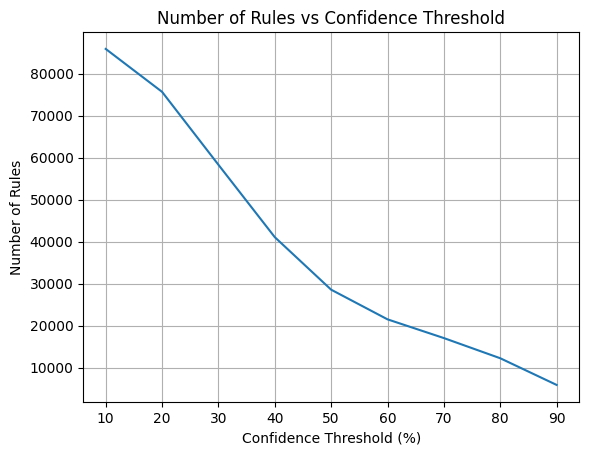

In [156]:
# number of rules with varying confidence thresholds
conf_levels = range(10, 100, 10)
num_rules_per_conf = []
for conf in conf_levels:
    rules = fpgrowth(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl")
    rules_df = pd.DataFrame(
        rules,
        columns=[
            "consequent",
            "antecedent",
            "abs_support",
            "%_support",
            "confidence",
            "lift",
        ],
    )
    rules_df = rules_df[rules_df["lift"] > 1]
    num_rules_per_conf.append(len(rules_df))
plt.plot(conf_levels, num_rules_per_conf, marker=None)
plt.xlabel("Confidence Threshold (%)")
plt.ylabel("Number of Rules")
plt.title("Number of Rules vs Confidence Threshold")
plt.xticks(conf_levels)
plt.grid()
plt.show()


In [157]:
conf = 50
rules = fpgrowth(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl")
rules_df = pd.DataFrame(
    rules,
    columns=[
        "consequent",
        "antecedent",
        "abs_support",
        "%_support",
        "confidence",
        "lift",
    ],
)
print(f"Regole estratte con Confidenza >= {conf}%: {len(rules)}")

Regole estratte con Confidenza >= 50%: 35528


In [158]:
rules_df = rules_df[rules_df["lift"] > 1]
rules_df.sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
35508,Is Reimplementation,"(HasImplementations, Has Family)",1317,6.019471,0.591113,5.111843
35500,Is Reimplementation,"(HasImplementations, NoAlternates)",1360,6.216006,0.558751,4.831982
35502,Is Reimplementation,"(HasImplementations, SmallGroup_PlayerRange)",1271,5.809223,0.553090,4.783023
35497,Is Reimplementation,"(HasImplementations, NoExpansions)",1664,7.605466,0.537294,4.646426
35495,Is Reimplementation,"(HasImplementations, NoExpansions, PreTeen(8-13)_AgeRec)",1240,5.667535,0.530822,4.590456
...,...,...,...,...,...,...
17830,NoExpansions,"(Modern_Year, PreTeen(8-13)_AgeRec, NoImplementations, Not Kickstarted, OriginalGame)",1913,8.743544,0.746682,1.000102
11667,SmallGroup_PlayerRange,"(HasAlternates, Not Has Family, NoExpansions, PreTeen(8-13)_AgeRec, NoImplementations, Not Kickstarted, OriginalGame)",1154,5.274464,0.503271,1.000096
11668,SmallGroup_PlayerRange,"(HasAlternates, Not Has Family, NoExpansions, PreTeen(8-13)_AgeRec, NoImplementations, Not Kickstarted)",1154,5.274464,0.503271,1.000096
6703,OriginalGame,"(Medium_Rating, SmallGroup_PlayerRange, PreTeen(8-13)_AgeRec)",3397,15.526304,0.884405,1.000046


In [159]:
rules_df[rules_df["consequent"] == "VeryHigh_Engagement"].sort_values(by="lift", ascending=False).head(20)

,consequent,antecedent,abs_support,%_support,confidence,lift
35121,VeryHigh_Engagement,"(Top500_Rank, HasAlternates)",1672,7.642031,0.743772,2.975497
35118,VeryHigh_Engagement,"(Top500_Rank, HasAlternates, HasCategory)",1672,7.642031,0.743772,2.975497
35109,VeryHigh_Engagement,"(Top500_Rank, HasCategory, PreTeen(8-13)_AgeRec)",1724,7.879702,0.715650,2.862991
35099,VeryHigh_Engagement,"(Top500_Rank, PreTeen(8-13)_AgeRec)",1724,7.879702,0.715650,2.862991
29887,VeryHigh_Engagement,"(HasExpansions, HasAlternates)",1675,7.655743,0.711555,2.846610
29844,VeryHigh_Engagement,"(Has Family, HasAlternates, HasCategory)",1538,7.029572,0.689686,2.759123
29876,VeryHigh_Engagement,"(HasExpansions, HasCategory)",2259,10.324969,0.677971,2.712257
35130,VeryHigh_Engagement,"(Top500_Rank,)",2344,10.713470,0.675310,2.701609
35112,VeryHigh_Engagement,"(Top500_Rank, HasCategory)",2344,10.713470,0.675310,2.701609
29866,VeryHigh_Engagement,"(HasExpansions, HasCategory, OriginalGame)",1849,8.451026,0.670413,2.682021


In [160]:
rules_df[rules_df["consequent"] == "Low_Engagement"].sort_values(by="lift", ascending=False).head(20)

,consequent,antecedent,abs_support,%_support,confidence,lift
24660,Low_Engagement,"(Low_Rating, NoCategory, NoAlternates, NoExpansions, NoImplementations)",1214,5.548700,0.526910,2.089209
24764,Low_Engagement,"(Low_Rating, Unranked_Rank, NoAlternates, NoExpansions, NoImplementations)",1214,5.548700,0.526910,2.089209
24847,Low_Engagement,"(Low_Rating, Unranked_Rank, NoCategory, NoAlternates, NoExpansions, NoImplementations)",1214,5.548700,0.526910,2.089209
24845,Low_Engagement,"(Low_Rating, Unranked_Rank, NoCategory, NoAlternates, NoExpansions, NoImplementations, OriginalGame)",1214,5.548700,0.526910,2.089209
24658,Low_Engagement,"(Low_Rating, NoCategory, NoAlternates, NoExpansions, NoImplementations, OriginalGame)",1214,5.548700,0.526910,2.089209
24762,Low_Engagement,"(Low_Rating, Unranked_Rank, NoAlternates, NoExpansions, NoImplementations, OriginalGame)",1214,5.548700,0.526910,2.089209
24656,Low_Engagement,"(Low_Rating, NoCategory, NoAlternates, NoExpansions, Not Kickstarted)",1208,5.521276,0.524989,2.081594
24760,Low_Engagement,"(Low_Rating, Unranked_Rank, NoAlternates, NoExpansions, Not Kickstarted)",1208,5.521276,0.524989,2.081594
24843,Low_Engagement,"(Low_Rating, Unranked_Rank, NoCategory, NoAlternates, NoExpansions, Not Kickstarted)",1208,5.521276,0.524989,2.081594
24842,Low_Engagement,"(Low_Rating, Unranked_Rank, NoCategory, NoAlternates, NoExpansions, OriginalGame)",1261,5.763518,0.524324,2.078958


In [161]:
rules_df[rules_df["consequent"] == "High_Rating"].sort_values(by="lift", ascending=False).head(20)

,consequent,antecedent,abs_support,%_support,confidence,lift
35133,High_Rating,"(Top500_Rank, VeryHigh_Engagement, HasCategory)",1335,6.101741,0.569539,2.492190
35134,High_Rating,"(Top500_Rank, VeryHigh_Engagement)",1335,6.101741,0.569539,2.492190
34255,High_Rating,"(HasExpansions, Modern_Year)",1343,6.138306,0.566906,2.480667
34296,High_Rating,"(Heavy_Weight, SmallGroup_PlayerRange)",1476,6.746195,0.517532,2.264615
34258,High_Rating,"(HasExpansions, Has Family)",1194,5.457288,0.516883,2.261777
34267,High_Rating,"(VeryHigh_Engagement, HasExpansions)",1357,6.202294,0.505589,2.212355
34265,High_Rating,"(VeryHigh_Engagement, HasExpansions, HasCategory)",1137,5.196764,0.503320,2.202428


In [162]:
rules_df[rules_df["consequent"] == "Low_Rating"].sort_values(by="lift", ascending=False).head(20)

,consequent,antecedent,abs_support,%_support,confidence,lift
27648,Low_Rating,"(Light_Weight, NoExpansions, NoImplementations, Not Kickstarted)",2356,10.768317,0.659021,1.991261
27644,Low_Rating,"(Light_Weight, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",2356,10.768317,0.659021,1.991261
27706,Low_Rating,"(Light_Weight, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted)",1850,8.455597,0.658597,1.989981
27704,Low_Rating,"(Light_Weight, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",1850,8.455597,0.658597,1.989981
27881,Low_Rating,"(Light_Weight, HasAlternates, NoExpansions, Not Kickstarted, OriginalGame)",1437,6.567942,0.654372,1.977213
27632,Low_Rating,"(Light_Weight, NoExpansions, Not Kickstarted, OriginalGame)",2623,11.988665,0.651192,1.967604
27696,Low_Rating,"(Light_Weight, Not Has Family, NoExpansions, Not Kickstarted, OriginalGame)",2047,9.356003,0.650048,1.964148
27800,Low_Rating,"(Light_Weight, Unranked_Rank, NoExpansions, NoImplementations, Not Kickstarted)",1630,7.450066,0.647854,1.957519
27836,Low_Rating,"(Light_Weight, Unranked_Rank, NoCategory, NoExpansions, NoImplementations, Not Kickstarted)",1630,7.450066,0.647854,1.957519
27749,Low_Rating,"(Light_Weight, NoCategory, NoExpansions, NoImplementations, Not Kickstarted)",1630,7.450066,0.647854,1.957519


# Classificatori rule-based

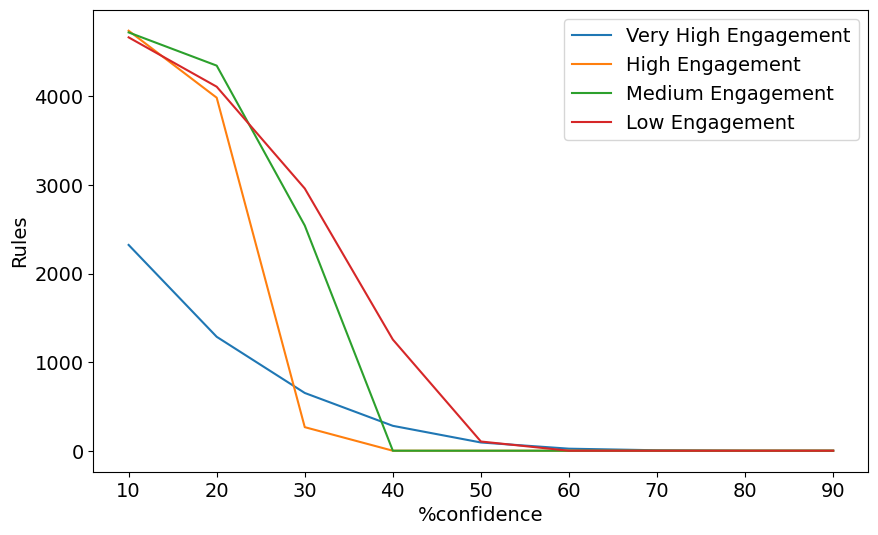

In [201]:
# Variazione del numero di itemset (maximal) contenenti "High Rating" o "Very High Engagement" in funzione del supporto minimo
filter_1 = []
filter_2 = []
filter_3 = []
filter_4 = []
max_conf = 100
for i in range(10, max_conf, 10):
    rules_raw = fpgrowth(X, target="r", supp=supp, zmin=2, conf=i, report="aScl")
    rules_df = pd.DataFrame(
        rules_raw,
        columns=["consequent", "antecedent", "abs_supp", "%_supp", "conf", "lift"]
    )
    filter_1.append(len(rules_df[rules_df["consequent"] == "VeryHigh_Engagement"]))
    filter_2.append(len(rules_df[rules_df["consequent"] == "High_Engagement"]))
    filter_3.append(len(rules_df[rules_df["consequent"] == "Medium_Engagement"]))
    filter_4.append(len(rules_df[rules_df["consequent"] == "Low_Engagement"]))
plt.figure(figsize=(10,6))
plt.plot(np.arange(10, max_conf, 10), filter_1, label="Very High Engagement")
plt.plot(np.arange(10, max_conf, 10), filter_2, label="High Engagement")
plt.plot(np.arange(10, max_conf, 10), filter_3, label="Medium Engagement")
plt.plot(np.arange(10, max_conf, 10), filter_4, label="Low Engagement")
plt.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("%confidence", fontsize=14)
plt.ylabel("Rules", fontsize=14)

plt.show()

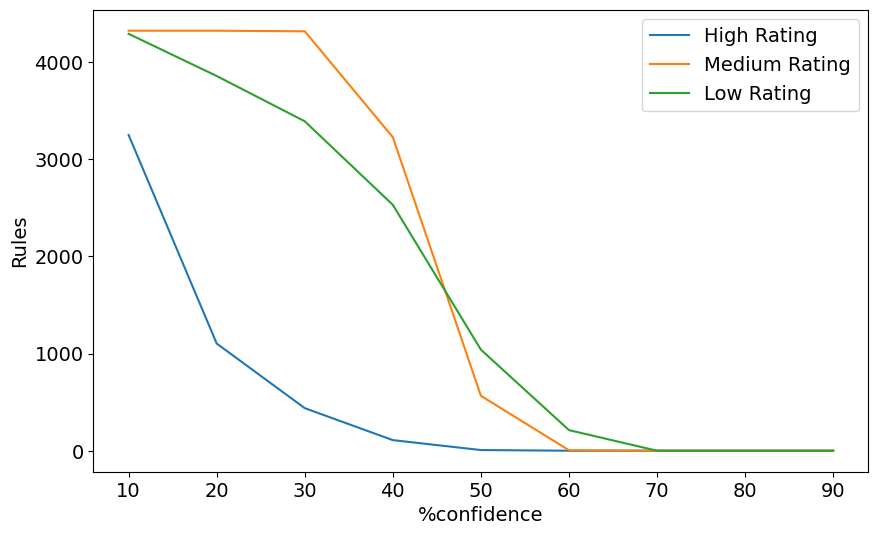

In [202]:
# Variazione del numero di itemset (maximal) contenenti "High Rating" o "Very High Engagement" in funzione del supporto minimo
filter_1 = []
filter_2 = []
filter_3 = []
max_conf = 100
for i in range(10, max_conf, 10):
    rules_raw = fpgrowth(X, target="r", supp=supp, zmin=2, conf=i, report="aScl")
    rules_df = pd.DataFrame(
        rules_raw,
        columns=["consequent", "antecedent", "abs_supp", "%_supp", "conf", "lift"]
    )
    filter_1.append(len(rules_df[rules_df["consequent"] == "High_Rating"]))
    filter_2.append(len(rules_df[rules_df["consequent"] == "Medium_Rating"]))
    filter_3.append(len(rules_df[rules_df["consequent"] == "Low_Rating"]))
plt.figure(figsize=(10,6))
plt.plot(np.arange(10, max_conf, 10), filter_1, label="High Rating")
plt.plot(np.arange(10, max_conf, 10), filter_2, label="Medium Rating")
plt.plot(np.arange(10, max_conf, 10), filter_3, label="Low Rating")
plt.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.xlabel("%confidence", fontsize=14)
plt.ylabel("Rules", fontsize=14)
plt.yticks(fontsize=14)

plt.show()

Default Class: Low_Engagement
Esecuzione FPGrowth...
Regole totali ibride: 80
Regole usate per il voto: 80
Inizio predizione (Voting)...
------------------------------
F1-Score: 0.40116802906017324
F1-Score (Weighted): 0.4003
Copertura Regole: 100.00%

--- Classification Report ---
                     precision    recall  f1-score   support

    High_Engagement       0.42      0.17      0.24      1662
     Low_Engagement       0.42      0.37      0.39      1613
  Medium_Engagement       0.34      0.39      0.36      1658
VeryHigh_Engagement       0.50      0.79      0.61      1631

           accuracy                           0.43      6564
          macro avg       0.42      0.43      0.40      6564
       weighted avg       0.42      0.43      0.40      6564


--- Confusion Matrix ---


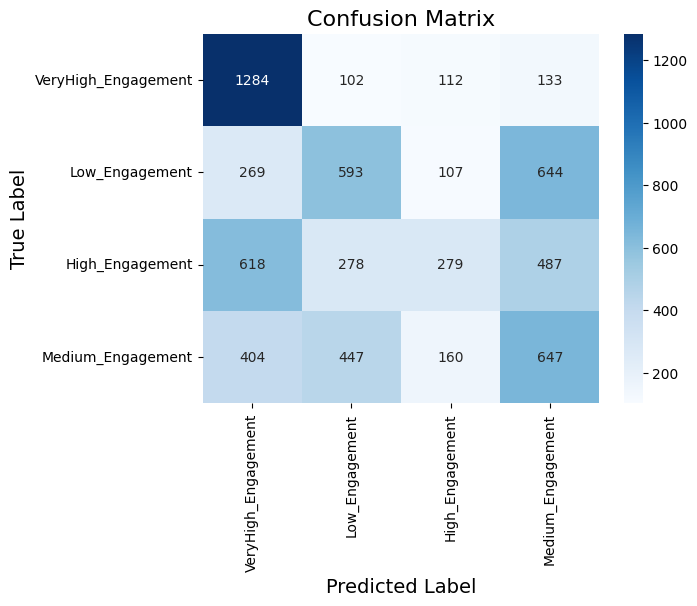

[[1284  102  112  133]
 [ 269  593  107  644]
 [ 618  278  279  487]
 [ 404  447  160  647]]


In [204]:
from collections import Counter
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# --- 1. PREPARAZIONE ---
# X deve essere una lista di liste (transazioni)
target_classes = {"Low_Engagement", "Medium_Engagement", "High_Engagement", "VeryHigh_Engagement"}

x_train, x_test = train_test_split(X, test_size=0.3, random_state=0)

# Calcoliamo la Default Class (Majority Class)
train_labels = [next((item for item in rec if item in target_classes), None) for rec in x_train]
default_class = Counter(train_labels).most_common(1)[0][0]
print(f"Default Class: {default_class}")


# --- 2. MINING E PRUNING INTELLIGENTE ---
print("Esecuzione FPGrowth...")
# Usiamo zmin=2 per evitare regole vuote o banali
rules_raw = fpgrowth(x_train, target="r", supp=supp, zmin=2, conf=30, report="aScl") # conf=20% in modo da avere più regole per le classi meno rappresentate

rules_df = pd.DataFrame(
    rules_raw,
    columns=["consequent", "antecedent", "abs_supp", "%_supp", "conf", "lift"]
)

# Filtriamo solo le regole che predicono il target
rules_df = rules_df[rules_df["consequent"].isin(target_classes) & (rules_df["lift"] > 1)]

# 1. Calcoliamo le Top per LIFT (Qualità)
top_lift = rules_df.sort_values(by="lift", ascending=False).groupby("consequent").head(10)

# 2. Calcoliamo le Top per SUPPORT (Quantità/Copertura)
top_supp = rules_df.sort_values(by="%_supp", ascending=False).groupby("consequent").head(10)

# 3. Uniamo i due set e rimuoviamo duplicati
# (Usiamo l'ID della regola o resettiamo l'indice per unire)
combined_rules = pd.concat([top_lift, top_supp]).drop_duplicates(subset=["consequent", "antecedent"])

print(f"Regole totali ibride: {len(combined_rules)}")


rules_pruned = combined_rules

voting_rules = []
for _, row in rules_pruned.iterrows():
    voting_rules.append({
        "consequent": row["consequent"],
        "antecedent": set(row["antecedent"]),
        "lift": row["lift"],   # Il "peso" del voto
        "conf": row["conf"]    # Alternativa: usare confidenza
    })

print(f"Regole usate per il voto: {len(voting_rules)}")

# --- 2. FUNZIONE DI PREDIZIONE (WEIGHTED VOTING) ---

def predict_voting(record, rules, default_class):
    record_set = set(record)
    
    # Inizializziamo i punteggi per ogni classe a 0
    # Assicurati che score_board contenga tutte le tue classi
    score_board = {cls: 0 for cls in target_classes}
    
    rules_triggered = 0
    
    for rule in rules:
        # Se la regola si applica al record
        if rule["antecedent"].issubset(record_set):
            # Aggiungiamo il Lift al punteggio della classe predetta
            # (Puoi provare anche rule["conf"] o rule["lift"] * rule["conf"])
            score_board[rule["consequent"]] += rule["lift"]
            rules_triggered += 1
            
    # Se nessuna regola si è attivata, usiamo il default
    if rules_triggered == 0:
        return default_class
    
    # Restituiamo la classe con il punteggio più alto
    return max(score_board, key=score_board.get)

# --- 3. VALUTAZIONE ---
correct = 0
total = 0
uncovered_count = 0

# --- LISTE PER SALVARE I RISULTATI ---
y_true = []
y_pred = []

# Variabili per statistiche interne (opzionale)
uncovered_count = 0 

print("Inizio predizione (Voting)...")

for record in x_test:
    # 1. Estrazione Ground Truth
    true_label = next((item for item in record if item in target_classes), None)
    
    # 2. Pulizia record per il test
    record_features = [item for item in record if item not in target_classes]
    
    if true_label:
        # Eseguiamo la predizione
        prediction = predict_voting(record_features, voting_rules, default_class)
        
        # Salviamo nelle liste per sklearn
        y_true.append(true_label)
        y_pred.append(prediction)
        
        # Controllo di copertura (se nessuna regola si è attivata)
        matches_any = any(rule["antecedent"].issubset(set(record_features)) for rule in voting_rules)
        if not matches_any:
            uncovered_count += 1

# --- CALCOLO METRICHE ---

# 1. F1 Score Globale (Weighted è meglio se le classi sono sbilanciate)
f1 = f1_score(y_true, y_pred, average = 'macro')
f1_w = f1_score(y_true, y_pred, average='weighted')

print("-" * 30)
print(f"F1-Score: {f1}")
print(f"F1-Score (Weighted): {f1_w:.4f}")
print(f"Copertura Regole: {((len(y_true) - uncovered_count) / len(y_true))*100:.2f}%")

# 2. Report Dettagliato (F1 per ogni classe)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred))

# 3. Matrice di Confusione (Opzionale ma utilissima per capire gli errori)
# Ti mostra se il modello confonde classi vicine (es. High vs VeryHigh)
cm = confusion_matrix(y_true, y_pred, labels=list(target_classes))
print("\n--- Confusion Matrix ---")
#heatmap per visualizzare meglio
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_classes, yticklabels=target_classes, cmap='Blues')
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.show()
print(cm)

Default Class: Medium_Rating
Esecuzione Apriori...
Regole totali ibride: 60
Regole usate per il voto: 60
Inizio predizione (Voting)...
------------------------------
F1-Score: 0.5083
F1-Score (Weighted): 0.4835
Copertura Regole: 100.00%

--- Classification Report ---
               precision    recall  f1-score   support

  High_Rating       0.49      0.67      0.57      1532
   Low_Rating       0.51      0.78      0.62      2149
Medium_Rating       0.58      0.24      0.34      2883

     accuracy                           0.52      6564
    macro avg       0.53      0.56      0.51      6564
 weighted avg       0.54      0.52      0.48      6564


--- Confusion Matrix ---


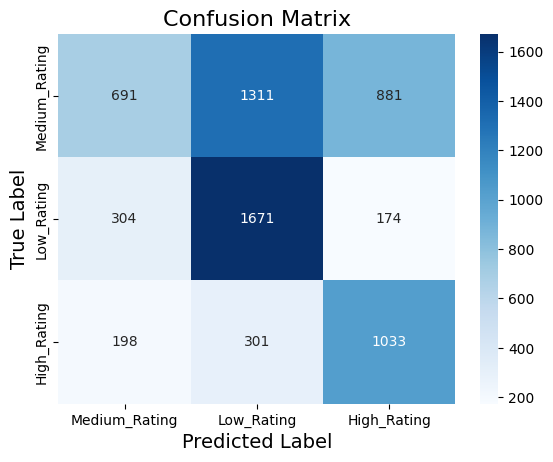

[[ 691 1311  881]
 [ 304 1671  174]
 [ 198  301 1033]]


In [205]:
from collections import Counter
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# --- 1. PREPARAZIONE ---
# X deve essere una lista di liste (transazioni)
target_classes = {"High_Rating", "Medium_Rating", "Low_Rating"}

x_train, x_test = train_test_split(X, test_size=0.3, random_state=0)

# Calcoliamo la Default Class (Majority Class)
train_labels = [next((item for item in rec if item in target_classes), None) for rec in x_train]
default_class = Counter(train_labels).most_common(1)[0][0]
print(f"Default Class: {default_class}")


# --- 2. MINING E PRUNING INTELLIGENTE ---
print("Esecuzione Apriori...")
# Usiamo zmin=2 per evitare regole vuote o banali
rules_raw = fpgrowth(x_train, target="r", supp=supp, zmin=2, conf=30, report="aScl") 

rules_df = pd.DataFrame(
    rules_raw,
    columns=["consequent", "antecedent", "abs_supp", "%_supp", "conf", "lift"]
)

# Filtriamo solo le regole che predicono il target
rules_df = rules_df[rules_df["consequent"].isin(target_classes) & (rules_df["lift"] > 1)]

# 1. Calcoliamo le Top per LIFT (Qualità)
top_lift = rules_df.sort_values(by="lift", ascending=False).groupby("consequent").head(10)

# 2. Calcoliamo le Top per SUPPORT (Quantità/Copertura)
top_supp = rules_df.sort_values(by="%_supp", ascending=False).groupby("consequent").head(10)

# 3. Uniamo i due set e rimuoviamo duplicati
# (Usiamo l'ID della regola o resettiamo l'indice per unire)
combined_rules = pd.concat([top_lift, top_supp]).drop_duplicates(subset=["consequent", "antecedent"])

print(f"Regole totali ibride: {len(combined_rules)}")


rules_pruned = combined_rules

voting_rules = []
for _, row in rules_pruned.iterrows():
    voting_rules.append({
        "consequent": row["consequent"],
        "antecedent": set(row["antecedent"]),
        "lift": row["lift"],   # Il "peso" del voto
        "conf": row["conf"]    # Alternativa: usare confidenza
    })

print(f"Regole usate per il voto: {len(voting_rules)}")

# --- 2. FUNZIONE DI PREDIZIONE (WEIGHTED VOTING) ---

def predict_voting(record, rules, default_class):
    record_set = set(record)
    
    # Inizializziamo i punteggi per ogni classe a 0
    # Assicurati che score_board contenga tutte le tue classi
    score_board = {cls: 0 for cls in target_classes}
    
    rules_triggered = 0
    
    for rule in rules:
        # Se la regola si applica al record
        if rule["antecedent"].issubset(record_set):
            # Aggiungiamo il Lift al punteggio della classe predetta
            # (Puoi provare anche rule["conf"] o rule["lift"] * rule["conf"])
            score_board[rule["consequent"]] += rule["lift"]
            rules_triggered += 1
            
    # Se nessuna regola si è attivata, usiamo il default
    if rules_triggered == 0:
        return default_class
    
    # Restituiamo la classe con il punteggio più alto
    return max(score_board, key=score_board.get)

# --- 3. VALUTAZIONE ---
correct = 0
total = 0
uncovered_count = 0

# --- LISTE PER SALVARE I RISULTATI ---
y_true = []
y_pred = []

# Variabili per statistiche interne (opzionale)
uncovered_count = 0 

print("Inizio predizione (Voting)...")

for record in x_test:
    # 1. Estrazione Ground Truth
    true_label = next((item for item in record if item in target_classes), None)
    
    # 2. Pulizia record per il test
    record_features = [item for item in record if item not in target_classes]
    
    if true_label:
        # Eseguiamo la predizione
        prediction = predict_voting(record_features, voting_rules, default_class)
        
        # Salviamo nelle liste per sklearn
        y_true.append(true_label)
        y_pred.append(prediction)
        
        # Controllo di copertura (se nessuna regola si è attivata)
        matches_any = any(rule["antecedent"].issubset(set(record_features)) for rule in voting_rules)
        if not matches_any:
            uncovered_count += 1

# --- CALCOLO METRICHE ---

# 1. F1 Score Globale (Weighted è meglio se le classi sono sbilanciate)
f1 = f1_score(y_true, y_pred, average = 'macro')
f1_w = f1_score(y_true, y_pred, average='weighted')

print("-" * 30)
print(f"F1-Score: {f1:.4f}")
print(f"F1-Score (Weighted): {f1_w:.4f}")
print(f"Copertura Regole: {((len(y_true) - uncovered_count) / len(y_true))*100:.2f}%")

# 2. Report Dettagliato (F1 per ogni classe)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred))

# 3. Matrice di Confusione (Opzionale ma utilissima per capire gli errori)
# Ti mostra se il modello confonde classi vicine (es. High vs VeryHigh)
cm = confusion_matrix(y_true, y_pred, labels=list(target_classes))
print("\n--- Confusion Matrix ---")
#heatmap per visualizzare meglio
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_classes, yticklabels=target_classes, cmap='Blues')
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.show()
print(cm)